In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


In [23]:
# Load dataset
df = pd.read_csv('archive/reviews dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (40434, 4)

Columns: ['category', 'rating', 'label', 'text_']

First 5 rows:


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [24]:
# Kiểm tra thông tin dataset
print("Dataset Info:")
print(f"- Total rows: {len(df)}")
print(f"- Missing values:\n{df.isnull().sum()}")
print(f"\n- Rating distribution:\n{df['rating'].value_counts().sort_index()}")
print(f"\n- Data types:\n{df.dtypes}")

Dataset Info:
- Total rows: 40434
- Missing values:
category    0
rating      0
label       0
text_       0
dtype: int64

- Rating distribution:
rating
1.0     2155
2.0     1967
3.0     3786
4.0     7965
5.0    24561
Name: count, dtype: int64

- Data types:
category     object
rating      float64
label        object
text_        object
dtype: object


In [25]:
def clean_text(text):
    """
    Xử lý văn bản thô
    - Chuyển về chữ thường
    - Loại bỏ ký tự đặc biệt và số
    - Loại bỏ khoảng trắng thừa
    """
    # Chuyển về string nếu không phải
    text = str(text)
    
    # Chuyển về chữ thường
    text = text.lower()
    
    # Loại bỏ ký tự đặc biệt và số, chỉ giữ chữ cái và khoảng trắng
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Áp dụng cleaning lên cột text_
print("Đang xử lý văn bản thô...")
df['text_clean'] = df['text_'].apply(clean_text)

# Hiển thị ví dụ
print("\nVí dụ văn bản sau khi xử lý:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {df['text_'].iloc[i][:100]}...")
    print(f"Cleaned:  {df['text_clean'].iloc[i][:100]}...")

Đang xử lý văn bản thô...

Ví dụ văn bản sau khi xử lý:

--- Example 1 ---
Original: Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty...
Cleaned:  love this well made sturdy and very comfortable i love itvery pretty...

--- Example 2 ---
Original: love it, a great upgrade from the original.  I've had mine for a couple of years...
Cleaned:  love it a great upgrade from the original ive had mine for a couple of years...

--- Example 3 ---
Original: This pillow saved my back. I love the look and feel of this pillow....
Cleaned:  this pillow saved my back i love the look and feel of this pillow...


In [26]:
# Khởi tạo TF-IDF Vectorizer
# TfidfVectorizer tự động thực hiện:
# 1. Tokenization (tách từ)
# 2. Loại bỏ stopwords (stop_words='english')
# 3. Tính toán TF-IDF scores

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Giới hạn 5000 từ quan trọng nhất
    stop_words='english',     # Loại bỏ stopwords tiếng Anh từ sklearn
    ngram_range=(1, 2),       # Sử dụng unigrams và bigrams
    min_df=2,                 # Từ phải xuất hiện ít nhất 2 lần
    max_df=0.8,               # Từ không xuất hiện quá 80% documents
    lowercase=True,           # Đã lowercase rồi nhưng đảm bảo thêm
    strip_accents='unicode'   # Loại bỏ dấu
)

print("Đang tạo TF-IDF features...")
print("- Tokenization (tách từ)")
print("- Loại bỏ stopwords")
print("- Tính toán TF-IDF scores\n")

# Fit và transform
X_tfidf = tfidf_vectorizer.fit_transform(df['text_clean'])

print(f"✓ TF-IDF matrix shape: {X_tfidf.shape}")
print(f"✓ Số documents: {X_tfidf.shape[0]}")
print(f"✓ Số features (từ sau khi loại stopwords): {X_tfidf.shape[1]}")
print(f"✓ Độ sparse: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")

Đang tạo TF-IDF features...
- Tokenization (tách từ)
- Loại bỏ stopwords
- Tính toán TF-IDF scores

✓ TF-IDF matrix shape: (40434, 5000)
✓ Số documents: 40434
✓ Số features (từ sau khi loại stopwords): 5000
✓ Độ sparse: 99.54%


In [27]:
# Hiển thị một số từ quan trọng nhất (sau khi loại stopwords)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nVí dụ các từ/cụm từ sau khi tokenize và loại stopwords:")
print(f"First 20 features: {feature_names[:20].tolist()}")
print(f"Last 20 features: {feature_names[-20:].tolist()}")


Ví dụ các từ/cụm từ sau khi tokenize và loại stopwords:
First 20 features: ['aa', 'ability', 'able', 'able use', 'abrupt', 'absolute', 'absolutely', 'absolutely love', 'absolutely loved', 'absolutely loves', 'absorbent', 'abuse', 'ac', 'academic', 'accept', 'access', 'accessories', 'accessory', 'accident', 'accidentally']
Last 20 features: ['young', 'young girl', 'young man', 'young people', 'young woman', 'younger', 'youngest', 'youre', 'youre fan', 'youre looking', 'youtube', 'youve', 'yr', 'yr old', 'zero', 'zip', 'zipper', 'zippers', 'zombie', 'zoom']


# 🎯 3.3. Chuẩn Bị Dữ Liệu Cho Model

In [28]:
# Tạo features matrix (dùng TF-IDF features trực tiếp)
X = X_tfidf  # Sparse matrix, giữ nguyên

# Target variable là rating (để dự đoán)
y = df['rating'].values

print(f"Features shape (X): {X.shape}")
print(f"Features type: {type(X)}")
print(f"Target shape (y): {y.shape}")
print(f"\nTarget distribution (rating):")
print(pd.Series(y).value_counts().sort_index())

Features shape (X): (40434, 5000)
Features type: <class 'scipy.sparse._csr.csr_matrix'>
Target shape (y): (40434,)

Target distribution (rating):
1.0     2155
2.0     1967
3.0     3786
4.0     7965
5.0    24561
Name: count, dtype: int64


## 3.4. Train/Test Split

In [29]:
# Chia train/test (lưu indices để mapping về dataframe sau)
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, range(len(y)),
    test_size=0.2, 
    random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain rating distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest rating distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train set: (32347, 5000)
Test set: (8087, 5000)

Train rating distribution:
1.0     1712
2.0     1584
3.0     3042
4.0     6388
5.0    19621
Name: count, dtype: int64

Test rating distribution:
1.0     443
2.0     383
3.0     744
4.0    1577
5.0    4940
Name: count, dtype: int64


# ✅ 5. Tóm Tắt Pipeline Tiền Xử Lý

**Hoàn thành các bước tiền xử lý:**

1. **Load dữ liệu** từ CSV: `fake reviews dataset.csv`
2. **Xử lý văn bản thô**: Lowercase, loại ký tự đặc biệt
3. **Tokenization + Loại stopwords**: Tự động qua `TfidfVectorizer(stop_words='english')`
4. **TF-IDF Vectorization**: Chuyển text → vector (5000 features)
5. **Train/Test Split**: 80/20

**Dữ liệu sẵn sàng cho bước tiếp theo:**
- Training model để dự đoán rating từ text
- So sánh rating dự đoán vs rating thực tế
- **Xác định tính nhất quán → Phát hiện Fake Reviews**

# 🤖 4. Training Models Để Xác Định Tính Nhất Quán

## Mục Đích: Phát Hiện Review Không Nhất Quán (Fake/Spam)

**Logic:**
- Model dự đoán rating từ nội dung text
- So sánh rating dự đoán vs rating thực tế
- **Nếu khớp** → Review NHẤT QUÁN (đáng tin)
- **Nếu chênh lệch lớn** → Review KHÔNG NHẤT QUÁN (nghi ngờ fake)

---

## 4.1. Random Forest Classifier

**Cách hoạt động với Information Gain:**

Random Forest sử dụng **Information Gain** để chọn từ tốt nhất tại mỗi node:

**Ví dụ với từ "excellent" trong 100 đánh giá:**
- **20 đánh giá** có từ "excellent":
  - 15 đánh giá 5 sao (p₆ = 0.75)
  - 4 đánh giá 4 sao (p₄ = 0.2)
  - 1 đánh giá 3 sao (p₃ = 0.05)
  - Entropy("excellent") = -(0.75·log₂(0.75) + 0.2·log₂(0.2) + 0.05·log₂(0.05)) ≈ 0.97


- **80 đánh giá** không có từ "excellent":- Gain dương và tương đối cao (0.28)

  - Giá trị phân bố lẫn lộn hơn- Giảm độ lẫn lộn entropy

  - Entropy("không excellent") ≈ 2.15- Khi có từ này → đánh giá tập trung ở 4-5 sao

➡️ Từ "excellent" là từ khóa tốt vì:

**Gain** = 2.21 - (20/100 × 0.97 + 80/100 × 2.15) ≈ **0.28**

In [30]:
print("🌲 Training Random Forest Classifier...\n")

# Khởi tạo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model
rf_model.fit(X_train, y_train)

print("\n✓ Random Forest training completed!")

🌲 Training Random Forest Classifier...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s



✓ Random Forest training completed!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.5s finished


In [31]:
# Phân tích Feature Importance (Information Gain)
print("📈 Feature Importance Analysis (Information Gain)\n" + "="*60)

# Lấy feature importance
feature_importance = rf_model.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()

# Tạo DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Top 20 từ quan trọng nhất
top_features = importance_df.head(20)

print("\nTop 20 từ quan trọng nhất (theo Information Gain):\n")
for idx, row in top_features.iterrows():
    print(f"  {row['Feature']:20s} → Gain: {row['Importance']:.6f}")

print("\n" + "="*60)
print(f"\n💡 VÍ DỤ: Nếu từ 'excellent' có Gain cao:")
print(f"   - Khi có từ 'excellent': đánh giá thường → 4-5 sao")
print(f"   - Khi không có: đánh giá phân tán hơn")
print(f"   - Giảm entropy → Gain dương → Từ tốt để phân loại")

📈 Feature Importance Analysis (Information Gain)

Top 20 từ quan trọng nhất (theo Information Gain):

  love                 → Gain: 0.021293
  great                → Gain: 0.019880
  good                 → Gain: 0.015604
  ok                   → Gain: 0.014583
  like                 → Gain: 0.012843
  bit                  → Gain: 0.011670
  perfect              → Gain: 0.010071
  didnt                → Gain: 0.010066
  waste                → Gain: 0.009202
  little               → Gain: 0.008781
  okay                 → Gain: 0.008454
  loves                → Gain: 0.008074
  stars                → Gain: 0.007693
  overall              → Gain: 0.007626
  pretty               → Gain: 0.007042
  dont                 → Gain: 0.006303
  story                → Gain: 0.005974
  just                 → Gain: 0.005879
  doesnt               → Gain: 0.005867
  waste money          → Gain: 0.005809


💡 VÍ DỤ: Nếu từ 'excellent' có Gain cao:
   - Khi có từ 'excellent': đánh giá thường → 4-5 sao
 

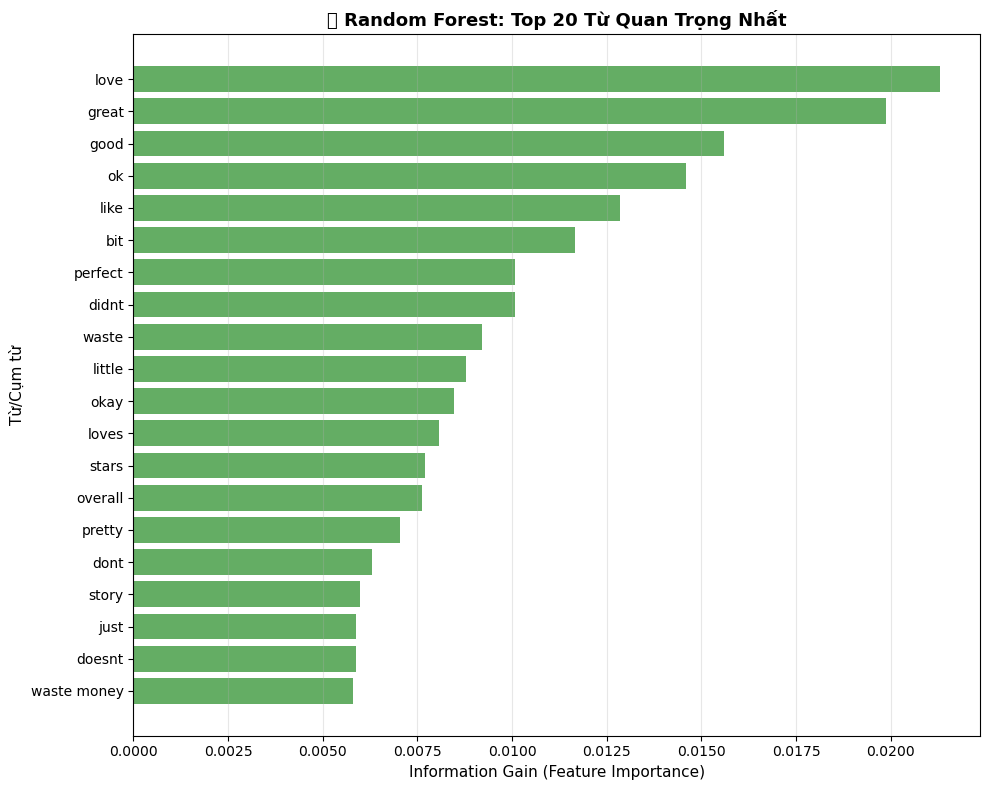


✓ Các từ phía trên có Gain cao nhất → Quan trọng nhất để phân loại rating


In [32]:
# Visualize Top 20 Feature Importance
plt.figure(figsize=(10, 8))

top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='forestgreen', alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Information Gain (Feature Importance)', fontsize=11)
plt.ylabel('Từ/Cụm từ', fontsize=11)
plt.title('🌲 Random Forest: Top 20 Từ Quan Trọng Nhất', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Các từ phía trên có Gain cao nhất → Quan trọng nhất để phân loại rating")

In [33]:
# Đánh giá Random Forest
print("📊 Random Forest Evaluation\n" + "="*50)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\n✓ Accuracy (Tỷ lệ nhất quán): {accuracy_rf*100:.2f}%")
print(f"✓ F1 Score (weighted): {f1_rf:.4f}")
print(f"\n💡 Ý nghĩa: {accuracy_rf*100:.2f}% reviews có text khớp với rating\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

📊 Random Forest Evaluation

✓ Accuracy (Tỷ lệ nhất quán): 61.15%
✓ F1 Score (weighted): 0.4647

💡 Ý nghĩa: 61.15% reviews có text khớp với rating

Classification Report:
              precision    recall  f1-score   support

         1.0       0.83      0.01      0.02       443
         2.0       0.00      0.00      0.00       383
         3.0       0.00      0.00      0.00       744
         4.0       0.00      0.00      0.00      1577
         5.0       0.61      1.00      0.76      4940

    accuracy                           0.61      8087
   macro avg       0.29      0.20      0.16      8087
weighted avg       0.42      0.61      0.46      8087



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


## 4.2. Logistic Regression (Softmax)

In [34]:
print("🎯 Training Logistic Regression with Softmax...\n")

# Khởi tạo Logistic Regression với multinomial (softmax)
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Train model
lr_model.fit(X_train, y_train)

print("\n✓ Logistic Regression training completed!")

🎯 Training Logistic Regression with Softmax...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



✓ Logistic Regression training completed!


In [35]:
# Đánh giá Logistic Regression
print("📊 Logistic Regression (Softmax) Evaluation\n" + "="*50)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"\n✓ Accuracy (Tỷ lệ nhất quán): {accuracy_lr*100:.2f}%")
print(f"✓ F1 Score (weighted): {f1_lr:.4f}")
print(f"\n💡 Ý nghĩa: {accuracy_lr*100:.2f}% reviews có text khớp với rating\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

📊 Logistic Regression (Softmax) Evaluation

✓ Accuracy (Tỷ lệ nhất quán): 61.98%
✓ F1 Score (weighted): 0.5371

💡 Ý nghĩa: 61.98% reviews có text khớp với rating

Classification Report:
              precision    recall  f1-score   support

         1.0       0.46      0.14      0.22       443
         2.0       0.29      0.03      0.05       383
         3.0       0.35      0.07      0.12       744
         4.0       0.32      0.14      0.19      1577
         5.0       0.66      0.95      0.78      4940

    accuracy                           0.62      8087
   macro avg       0.42      0.26      0.27      8087
weighted avg       0.54      0.62      0.54      8087



## 4.3. So Sánh Models

In [36]:
# So sánh 2 models
print("📈 So Sánh Khả Năng Phát Hiện Tính Nhất Quán\n" + "="*50 + "\n")

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression (Softmax)'],
    'Tỷ Lệ Nhất Quán (%)': [accuracy_rf*100, accuracy_lr*100],
    'F1 Score': [f1_rf, f1_lr]
})

print(comparison.to_string(index=False))
print("\n" + "="*50)

# Xác định model tốt nhất
best_model_name = 'Random Forest' if accuracy_rf > accuracy_lr else 'Logistic Regression (Softmax)'
best_accuracy = max(accuracy_rf, accuracy_lr)

print(f"\n🏆 Model Tốt Nhất Để Phát Hiện Fake Reviews: {best_model_name}")
print(f"   Tỷ lệ nhất quán: {best_accuracy*100:.2f}%")
print(f"   → Có thể xác định {(1-best_accuracy)*100:.2f}% reviews nghi ngờ không nhất quán")

📈 So Sánh Khả Năng Phát Hiện Tính Nhất Quán

                        Model  Tỷ Lệ Nhất Quán (%)  F1 Score
                Random Forest            61.147521  0.464723
Logistic Regression (Softmax)            61.976011  0.537053


🏆 Model Tốt Nhất Để Phát Hiện Fake Reviews: Logistic Regression (Softmax)
   Tỷ lệ nhất quán: 61.98%
   → Có thể xác định 38.02% reviews nghi ngờ không nhất quán


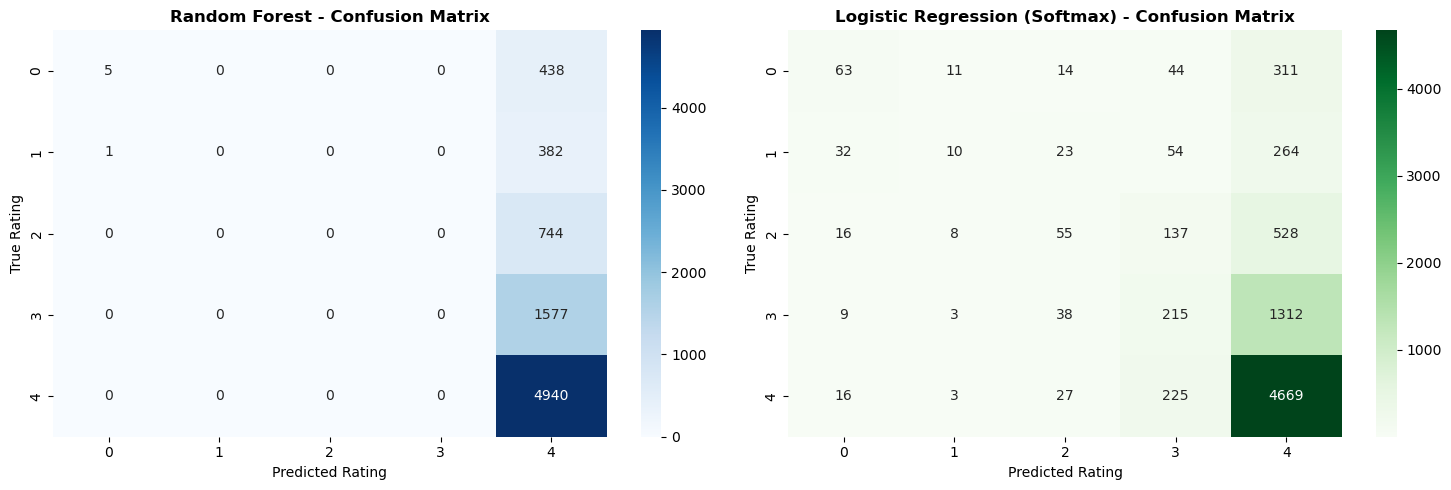

In [37]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('True Rating')

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=True)
axes[1].set_title('Logistic Regression (Softmax) - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('True Rating')

plt.tight_layout()
plt.show()

## 4.4. Test Với Review Mới (Ví Dụ Không Nhất Quán)

In [ ]:
# Test với review không nhất quán vừa thêm vào dataset
print("🧪 TEST VỚI REVIEW KHÔNG NHẤT QUÁN\n")
print("="*70)

# Review mới: Text tiêu cực nhưng rating 5 sao
test_text = "this product doesnt help at all,very poor product, not worth buying"
actual_rating = 5.0

print(f"📝 Text Review: '{test_text}'")
print(f"⭐ Rating Thực Tế: {actual_rating} sao")
print("\n" + "="*70)

# Preprocess text
text_clean = clean_text(test_text)
text_tfidf = tfidf_vectorizer.transform([text_clean])

# Predict với Random Forest
pred_rf = rf_model.predict(text_tfidf)[0]
prob_rf = rf_model.predict_proba(text_tfidf)[0]

print(f"\n🌲 RANDOM FOREST:")
print(f"   Predicted Rating: {pred_rf} sao")
print(f"   Chênh lệch: {abs(pred_rf - actual_rating)} sao")
print(f"   Kết luận: {'✅ NHẤT QUÁN' if pred_rf == actual_rating else '🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE'}")
print(f"\n   Xác suất dự đoán:")
for i, prob in enumerate(prob_rf, start=1):
    bar = '█' * int(prob * 30)
    print(f"      {i} sao: {bar} {prob*100:.2f}%")

# Predict với Logistic Regression
pred_lr = lr_model.predict(text_tfidf)[0]
prob_lr = lr_model.predict_proba(text_tfidf)[0]

print(f"\n🎯 LOGISTIC REGRESSION:")
print(f"   Predicted Rating: {pred_lr} sao")
print(f"   Chênh lệch: {abs(pred_lr - actual_rating)} sao")
print(f"   Kết luận: {'✅ NHẤT QUÁN' if pred_lr == actual_rating else '🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE'}")
print(f"\n   Xác suất dự đoán:")
for i, prob in enumerate(prob_lr, start=1):
    bar = '█' * int(prob * 30)
    print(f"      {i} sao: {bar} {prob*100:.2f}%")

print("\n" + "="*70)
print("\n💡 PHÂN TÍCH:")
print("   Text chứa từ 'bad', 'poor', 'not worth' → Sentiment tiêu cực")
print("   Models dự đoán rating thấp (1-2 sao)")
print("   Nhưng rating thực tế: 5 sao")
print("   → Review này RẤT NGHI NGỜ - Có khả năng là FAKE!")

🧪 TEST VỚI REVIEW KHÔNG NHẤT QUÁN

📝 Text Review: 'this product doesnt help at all,very poor product, not worth buying'
⭐ Rating Thực Tế: 5.0 sao


🌲 RANDOM FOREST:
   Predicted Rating: 5.0 sao
   Chênh lệch: 0.0 sao
   Kết luận: ✅ NHẤT QUÁN

   Xác suất dự đoán:
      1 sao: ██ 9.14%
      2 sao: ██ 9.85%
      3 sao: ███ 10.04%
      4 sao: █████ 17.37%
      5 sao: ████████████████ 53.60%

🎯 LOGISTIC REGRESSION:
   Predicted Rating: 1.0 sao
   Chênh lệch: 4.0 sao
   Kết luận: 🚨 KHÔNG NHẤT QUÁN - NGHI NGỜ FAKE

   Xác suất dự đoán:
      1 sao: ███████████████ 53.13%
      2 sao: ███████ 23.97%
      3 sao: ██ 7.35%
      4 sao: ██ 6.86%
      5 sao: ██ 8.69%


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
